In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn as sns

In [2]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, mean_absolute_percentage_error, r2_score
from darts import TimeSeries

In [3]:
STOCK = 'BTC'
TF = '1h'
LEVEL = 1
PRICE = 'close'
SEQ_LENGTH = 48
BATCH_SIZE = 8
TRAIN_SPLIT = 0.7
VAL_SPLIT = 0.1
TEST_SPLIT = 1 - (TRAIN_SPLIT+VAL_SPLIT)
DATA_TYPE = 'float32'
FILE_NAME = f'cnn/{STOCK}_{TF}/figs'

In [4]:
os.chdir(r'c:\\Users\\arvin\\Documents\\Coding Project\\V4\\Algotrading_RL\\src')
from utils.utils import CreateTimeFrames

In [5]:
df = pd.read_csv(f'data/{STOCK}USD_2023_2024.csv',
                  index_col = 'Gmt time')
df.index = pd.to_datetime(df.index, format='%d.%m.%Y %H:%M:%S.%f', errors='coerce')
df = df.rename(columns={'Date':'time', 'Open': 'open', 'High': 'high', 'Low': 'low', 'Close':'close', 'Volume':'volume'})


timeframes = [TF]
# timeframes = ['1min','5min','15min', '30min','1h', '4h','1d','1w','1m']
df = CreateTimeFrames(df,timeframes)
df_tf = df[TF]
df_tf = df_tf.iloc[-4050:,:]

In [6]:
def _naive_forecasting(actual: np.ndarray, seasonality: int = 1):
    # Naive forecasting method which just repeats previous samples
    return actual[:-seasonality]

def root_mean_squared_scaled_error(actual: np.ndarray, predicted: np.ndarray, seasonality: int = 1):
    # RMSSE - Root Mean Squared Scaled Error
    q = mean_squared_error(actual, predicted) / mean_squared_error(actual[seasonality:], _naive_forecasting(actual, seasonality))
    return np.sqrt(q)

def mean_absolute_scaled_error(actual: np.ndarray, predicted: np.ndarray, seasonality: int = 1):
    # MASE - Mean Absolute Scaled Error
    return mean_absolute_error(actual, predicted) / mean_absolute_error(actual[seasonality:], _naive_forecasting(actual, seasonality))

def calculate_metrics(actual, prediction, model_name, data_type):
    # Convert Darts TimeSeries to NumPy arrays if necessary
    if isinstance(actual, TimeSeries):
        actual = actual.values().flatten()
    if isinstance(prediction, TimeSeries):
        prediction = prediction.values().flatten()

    # Calculate metrics using scikit-learn functions
    metrics = {
        "MAE": mean_absolute_error(actual, prediction),
        "MSE": mean_squared_error(actual, prediction),
        "RMSE": root_mean_squared_error(actual, prediction),
        "RMSSE": root_mean_squared_scaled_error(actual, prediction),
        "MAPE": mean_absolute_percentage_error(actual, prediction) * 100,
        "MASE": mean_absolute_scaled_error(actual, prediction),
        "R2": r2_score(actual, prediction)
    }

    for metric_name, metric_value in metrics.items():
        value_str = f"{metric_value:.2f}"
        if metric_name == "MAPE":
            value_str += "%"
        print(f"{model_name} ({data_type}) | {metric_name}: {value_str}")

    return metrics

In [7]:
y_predictions = np.load(f'cnn/{STOCK}_{TF}/test_predictions.npy')
y_hat_test = y_predictions

y_hat_val = np.load(f'cnn/{STOCK}_{TF}/val_predictions.npy')
y_hat_train = np.load(f'cnn/{STOCK}_{TF}/train_predictions.npy')

In [8]:
y_predictions = np.vstack((y_hat_train, y_hat_val, y_hat_test))

y_predictions = y_predictions[-4024:, -1,:].squeeze()

y_hat_train = y_predictions[:2816]
y_hat_val = y_predictions[2816:-805]
y_hat_test = y_predictions[-805:]

In [9]:
len(y_hat_test)+len(y_hat_val)+len(y_hat_train)

4024

In [10]:
y_test = df_tf['close'][-len(y_hat_test):].to_numpy()
y_val = df_tf['close'][(-len(y_hat_test)-len(y_hat_val)):-len(y_hat_test)].to_numpy()
y_train = df_tf['close'][-len(y_hat_test)-len(y_hat_val)-len(y_hat_train):-len(y_hat_test)-len(y_hat_val)].to_numpy()


In [11]:
y_test.shape

(805,)

In [12]:
metrics_price = calculate_metrics(y_test,y_hat_test, {STOCK}, 'float32')

{'BTC'} (float32) | MAE: 190.11
{'BTC'} (float32) | MSE: 62356.27
{'BTC'} (float32) | RMSE: 249.71
{'BTC'} (float32) | RMSSE: 0.85
{'BTC'} (float32) | MAPE: 0.29%
{'BTC'} (float32) | MASE: 0.97
{'BTC'} (float32) | R2: 0.99


In [13]:
y_test.shape

(805,)

In [14]:
y_test.shape

(805,)

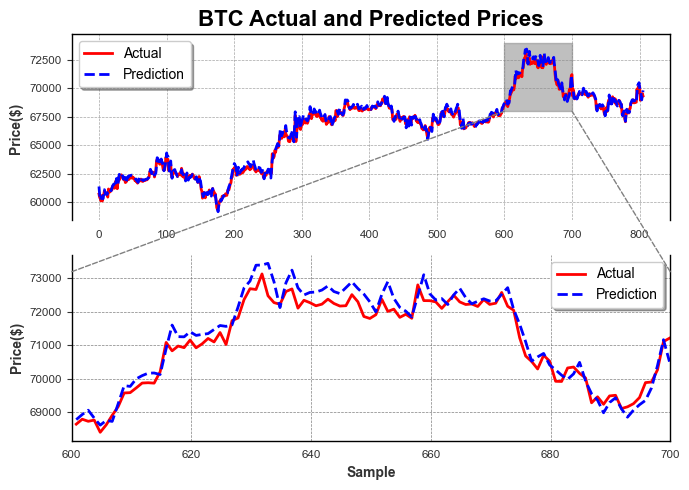

In [21]:
from matplotlib.patches import ConnectionPatch, Polygon


plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial']

b = len(y_test)
# Example data
t = np.linspace(0, b, b)
signal1 = y_test
signal2 = y_hat_test

t_zoom_start, t_zoom_end = 600, 700
mask = (t >= t_zoom_start) & (t <= t_zoom_end)

# Create the figure and axis
fig, axes = plt.subplots(2,1,figsize=(7, 5))

# Plot the data with default matplotlib colors
axes[0].plot(t, signal1, color='red', linewidth=2, markersize=5, label='Actual')  # Default blue
axes[0].plot(t, signal2, color='blue', linewidth=2, linestyle='--', markersize=5, label='Prediction')  # Default red

# Customize grid and background
axes[0].grid(color='gray', linestyle='--', linewidth=0.5, alpha=0.7)
axes[0].set_facecolor('white')

# Set labels and title with better formatting
axes[0].set_ylabel('Price($) ', fontsize=10, fontweight='bold')
axes[0].set_title(f'{STOCK} Actual and Predicted Prices', fontsize=16, fontweight='bold')

# Customize legend
axes[0].legend(loc='best', fontsize=10, frameon=True, shadow=True, fancybox=True)

axes[0].spines['top'].set_visible(True)
axes[0].spines['right'].set_visible(True)
# axes[0].spines['bottom'].set_visible(True)
axes[0].spines['left'].set_visible(True)

if STOCK=='ETH':
    axes[0].fill_betweenx([2480, 2750], t_zoom_start, t_zoom_end, color='gray', alpha=0.5)
else: 
    axes[0].fill_betweenx([68000, 74000], t_zoom_start, t_zoom_end, color='gray', alpha=0.5)
    



axes[1].plot(t[mask], signal1[mask], color='red', linewidth=2, markersize=5, label='Actual')
axes[1].plot(t[mask], signal2[mask], color='blue', linewidth=2, linestyle='--', markersize=5, label='Prediction')
axes[1].set_ylabel("Price($)", fontsize=10, fontweight='bold')
axes[1].set_xlim(t_zoom_start, t_zoom_end)
# axs[1].set_xlabel('Samples')
axes[1].grid(color='gray', linestyle='--', linewidth=0.5)  # Customize grid appearance
axes[1].legend(loc='best', fontsize=10, frameon=True, shadow=True, fancybox=True)

# axes[1].spines['top'].set_visible(True)
axes[1].spines['right'].set_visible(True)
axes[1].spines['bottom'].set_visible(True)
axes[1].spines['left'].set_visible(True)

axes[1].set_xlabel('Sample', fontsize=10, fontweight='bold')


# axes[1].set_facecolor('gray')


if STOCK=='ETH':
    con1 = ConnectionPatch(xyA=(t_zoom_start, 2750), coordsA=axes[1].transData,
                        xyB=(t_zoom_start, 2500), coordsB=axes[0].transData,
                        axesA=axes[1], axesB=axes[0], color="gray", linestyle="--")
    fig.add_artist(con1)

    con2 = ConnectionPatch(xyA=(t_zoom_end, 2750), coordsA=axes[1].transData,
                        xyB=(t_zoom_end, 2500), coordsB=axes[0].transData,
                        axesA=axes[1], axesB=axes[0], color="gray", linestyle="--")
    fig.add_artist(con2)
else:
    con1 = ConnectionPatch(xyA=(t_zoom_start, 73200), coordsA=axes[1].transData,
                        xyB=(t_zoom_start, 68000), coordsB=axes[0].transData,
                        axesA=axes[1], axesB=axes[0], color="gray", linestyle="--")
    fig.add_artist(con1)

    con2 = ConnectionPatch(xyA=(t_zoom_end, 73200), coordsA=axes[1].transData,
                        xyB=(t_zoom_end, 68000), coordsB=axes[0].transData,
                        axesA=axes[1], axesB=axes[0], color="gray", linestyle="--")
    fig.add_artist(con2)





# Improve layout and save the figure
plt.tight_layout()
plt.savefig(f'cnn/{STOCK}_{TF}/figs/ActualPrediction{STOCK}{TF}.png', dpi=300, bbox_inches='tight')
plt.show()


In [16]:
from utils.directional_prediction import *

In [17]:
close = df_tf['close'][-4024:]
train = close[:int(np.ceil(TRAIN_SPLIT*len(close)))]
val = close[int(np.ceil(TRAIN_SPLIT*len(close))): int(np.ceil( (TRAIN_SPLIT+VAL_SPLIT)*len(close) ))]
test = close[int(np.ceil((TRAIN_SPLIT+VAL_SPLIT)*len(close))):]
# assert len(train) + len(val) + len(test) == len(df_tf), f"The dimension of price is dividable to SPLIT numbers. Splited len is:{len(train)+len(val)+len(test)} but df len is:{len(df)} "
print(f'train size:{train.size}, val size:{val.size}, test size:{test.size}.')

train size:2817, val size:403, test size:804.


In [18]:
os.getcwd()

'c:\\Users\\arvin\\Documents\\Coding Project\\V4\\Algotrading_RL\\src'

In [19]:
y_hat_test.shape

(805,)

cnn/BTC_1h/figs (float32) | Train Accuracy: 66.36%
cnn/BTC_1h/figs (float32) | Validation Accuracy: 68.91%
cnn/BTC_1h/figs (float32) | Test Accuracy: 66.67%
cnn/BTC_1h/figs (float32) | Recall: 67.31%
cnn/BTC_1h/figs (float32) | Precision (Rise): 67.64%
cnn/BTC_1h/figs (float32) | Precision (Fall): 65.65%
cnn/BTC_1h/figs (float32) | F1 Score: 67.48%


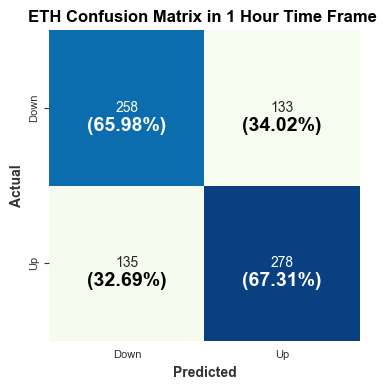

In [20]:
# true_labels, predicted_labels, metrics_direction = evaluate_directional_movement(y_train, y_hat_train[:,-1,:].squeeze(), y_val, y_hat_val[:,-1,:].squeeze(), y_test, y_hat_test[:,-1,:].squeeze(), model_name=FILE_NAME, data_type=DATA_TYPE, using_darts=False)
true_labels, predicted_labels, metrics_direction = evaluate_directional_movement(y_train, y_hat_train, y_val, y_hat_val, y_test, y_hat_test, model_name=FILE_NAME, data_type=DATA_TYPE, using_darts=False)
